# Compute Fourier Series Coefficients
* Consider various signals
* Coeffs computed by numerical integration 

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# Course utilities (do not modify this cell)        
import sys
import os
base_path = os.path.expanduser("~/Documents/GitHub/Signals_and_Systems")
sys.path.insert(0, base_path)
sys.path.insert(0, os.path.join(base_path, "courseutils"))

import basic_material as bm
print("Basic Material version:", bm.__version__)
bm.setup_environment()


Basic Material version: 16.002-0.1


In [3]:
colors = bm.get_colors()
import numpy as np
import matplotlib.pyplot as plt
import scipy as sc

import sympy as sp
from sympy import Symbol, oo, integrate 
from sympy import lambdify, Symbol, integrate
print("Running Sympy:",sp.__version__)
ts = Symbol('t')

from ipywidgets import interactive
from IPython.display import HTML

def H(t):
    return np.heaviside(t, 1)

Running Sympy: 1.13.3


In [4]:
KK = 8 # discrete plotting range
Krange = np.arange(-KK,KK+1,1)

## Plotting Functions

In [5]:
def compute_ck(T0,xftn):
    omega0 = 2*np.pi/T0
    tt = np.arange(0, T0, 1/10000)  # very fine time samples to compute cts signal
    x2 = lambda t,k: np.exp(-1j * k * omega0 * t) # exp
    prod = lambda t,k: xftn(t) * x2(t,k)/T0

    Cvalues = np.zeros((2*KK+1,1),dtype = 'complex_')
    for kk in Krange:
        Cvalues[KK+kk] = sc.integrate.simpson(prod(tt,kk), tt) # see page 7 of topic 6

    return Cvalues

def plot_fourier_coeffs(T0,x,Cvals,kn=None,an=None,bn=None):
    if kn is None:
        kn = []
    plot_tt = np.arange(-3*T0, 3*T0, 1/100)  # the time samples
    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(6,3), dpi=300)
    ax1.plot(plot_tt, x(plot_tt), 'b-', lw=2)
    ax1.set_title('Function')
    ax1.set_ylabel('$x(t)$')
    ax1.set_xlabel('$t$')
    bm.nicegrid(ax1)
    
    markerline, stemlines, baseline = ax2.stem(Krange, np.abs(Cvals), 'b-')
    plt.setp(stemlines, 'linewidth', 3)
    ax2.set_xlabel('k')
    ax2.set_xticks(np.arange(-KK+1,KK,2))
    if len(kn) > 0 and an is not None:
        markerline, stemlines, baseline = ax2.stem(
            kn,
            np.abs([an(n) for n in kn]) / 2,
            linefmt='c--',
            markerfmt='co',
            basefmt=' '
        )

    if len(kn) > 0 and bn is not None:
        markerline, stemlines, baseline = ax2.stem(
            kn,
            np.abs([bn(n) for n in kn]) / 2,
            linefmt='r--',
            markerfmt='ro',
            basefmt=' '
        )

    plt.setp(stemlines, 'linewidth', 1)
    plt.setp(stemlines, 'linewidth', 1)
    plt.setp(markerline, markersize = 2)
        
    ax2.set_title('Fourier Coefficients')
    ax2.set_ylabel('$|c_k|$')
    ax2.set_ylim(0,1.1)
    plt.tight_layout()
    bm.nicegrid(ax2)
    plt.show()
    return

## Cosine

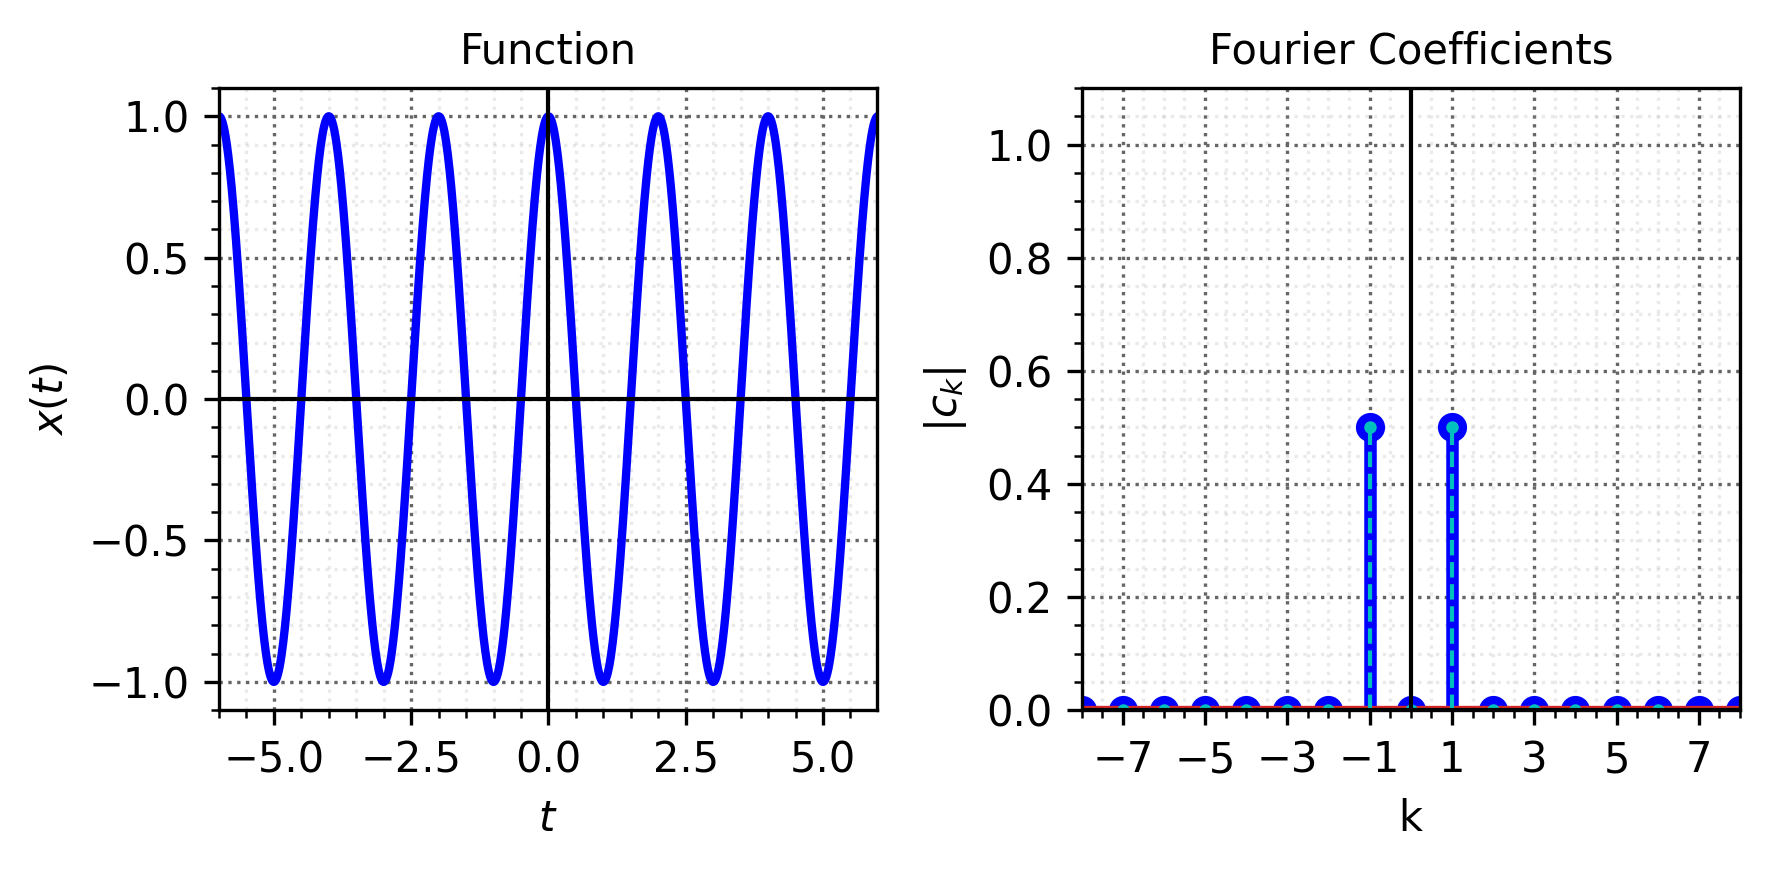

In [6]:
T0 = 2
x1 = lambda t: np.cos(2*np.pi*t/T0)  

# FUAY pg210
kn = np.arange(-7,7); an = lambda n: 1 if abs(n) == 1 else 0  

C_ex1 = compute_ck(T0,x1)
plot_fourier_coeffs(T0,x1,C_ex1,kn,an)

## Sine

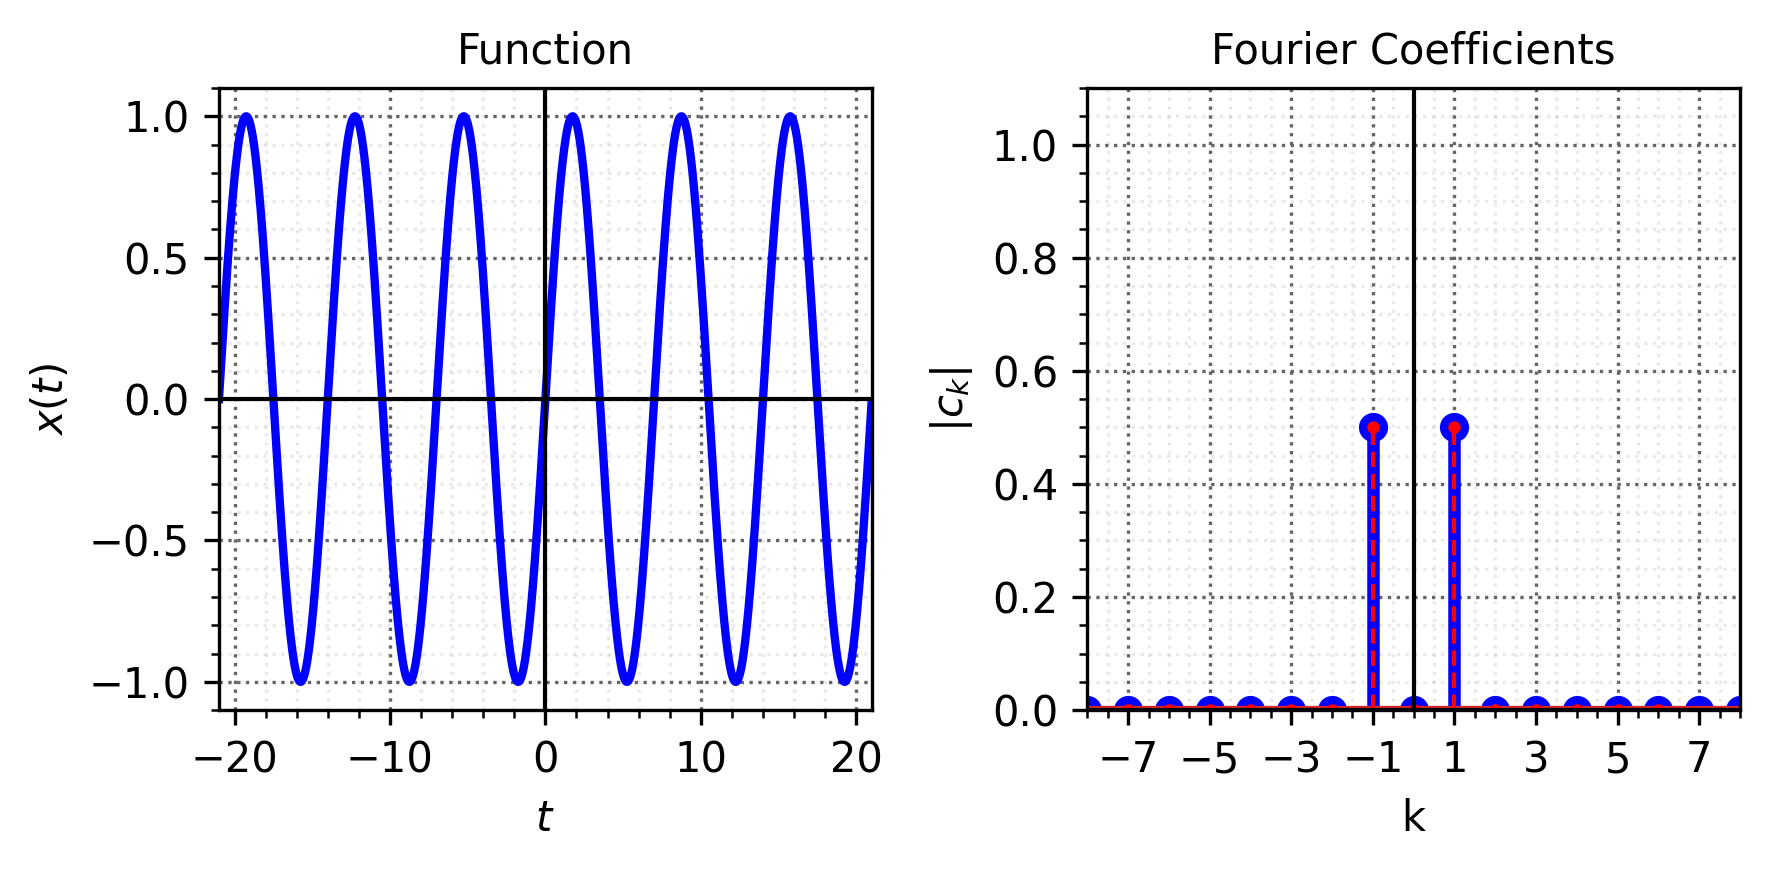

In [7]:
T0 = 7
x2 = lambda t: np.sin(2*np.pi*t/T0)  

# FUAY pg210
kn = np.arange(-7,7); bn = lambda n: 1 if abs(n) == 1 else 0  

C_ex2 = compute_ck(T0,x2)
plot_fourier_coeffs(T0,x2,C_ex2,kn,bn=bn)

## Multiple Cosines

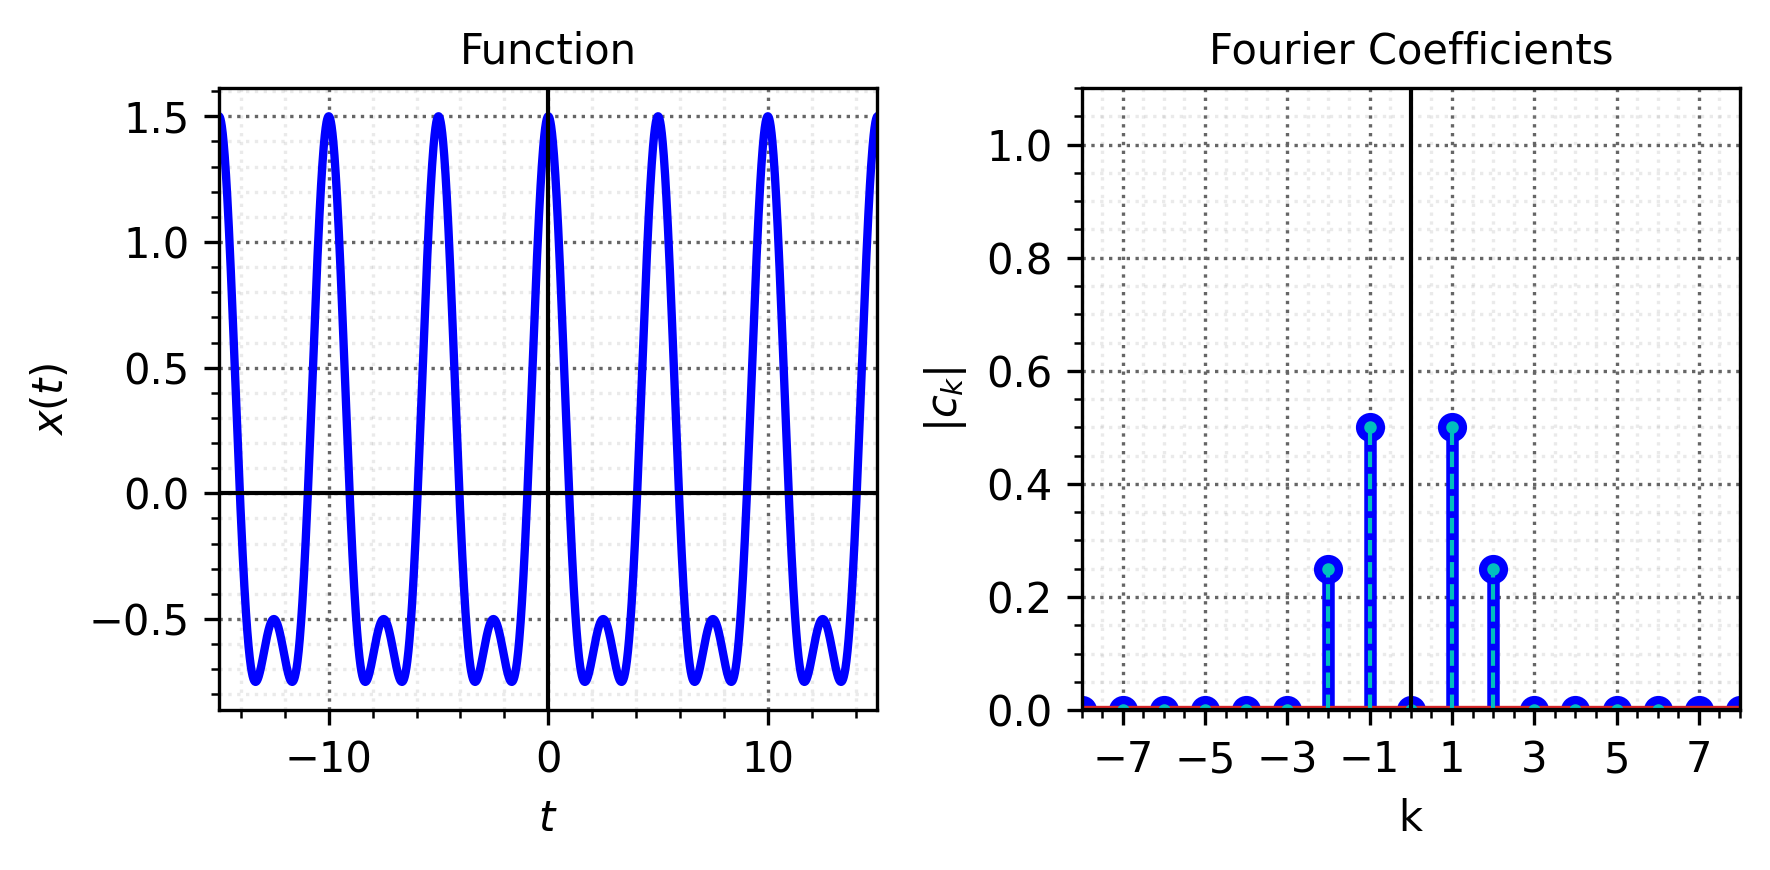

In [8]:
T0 = 5
x3 = lambda t: np.cos(2*np.pi*t/T0) + 0.5*np.cos(4*np.pi*t/T0)  

# FUAY pg210
kn = np.arange(-7,7); an = lambda n: 1 if abs(n) == 1 else (0.5 if abs(n) == 2 else 0)  

C_ex3 = compute_ck(T0,x3)
plot_fourier_coeffs(T0,x3,C_ex3,kn,an)

## Square Wave

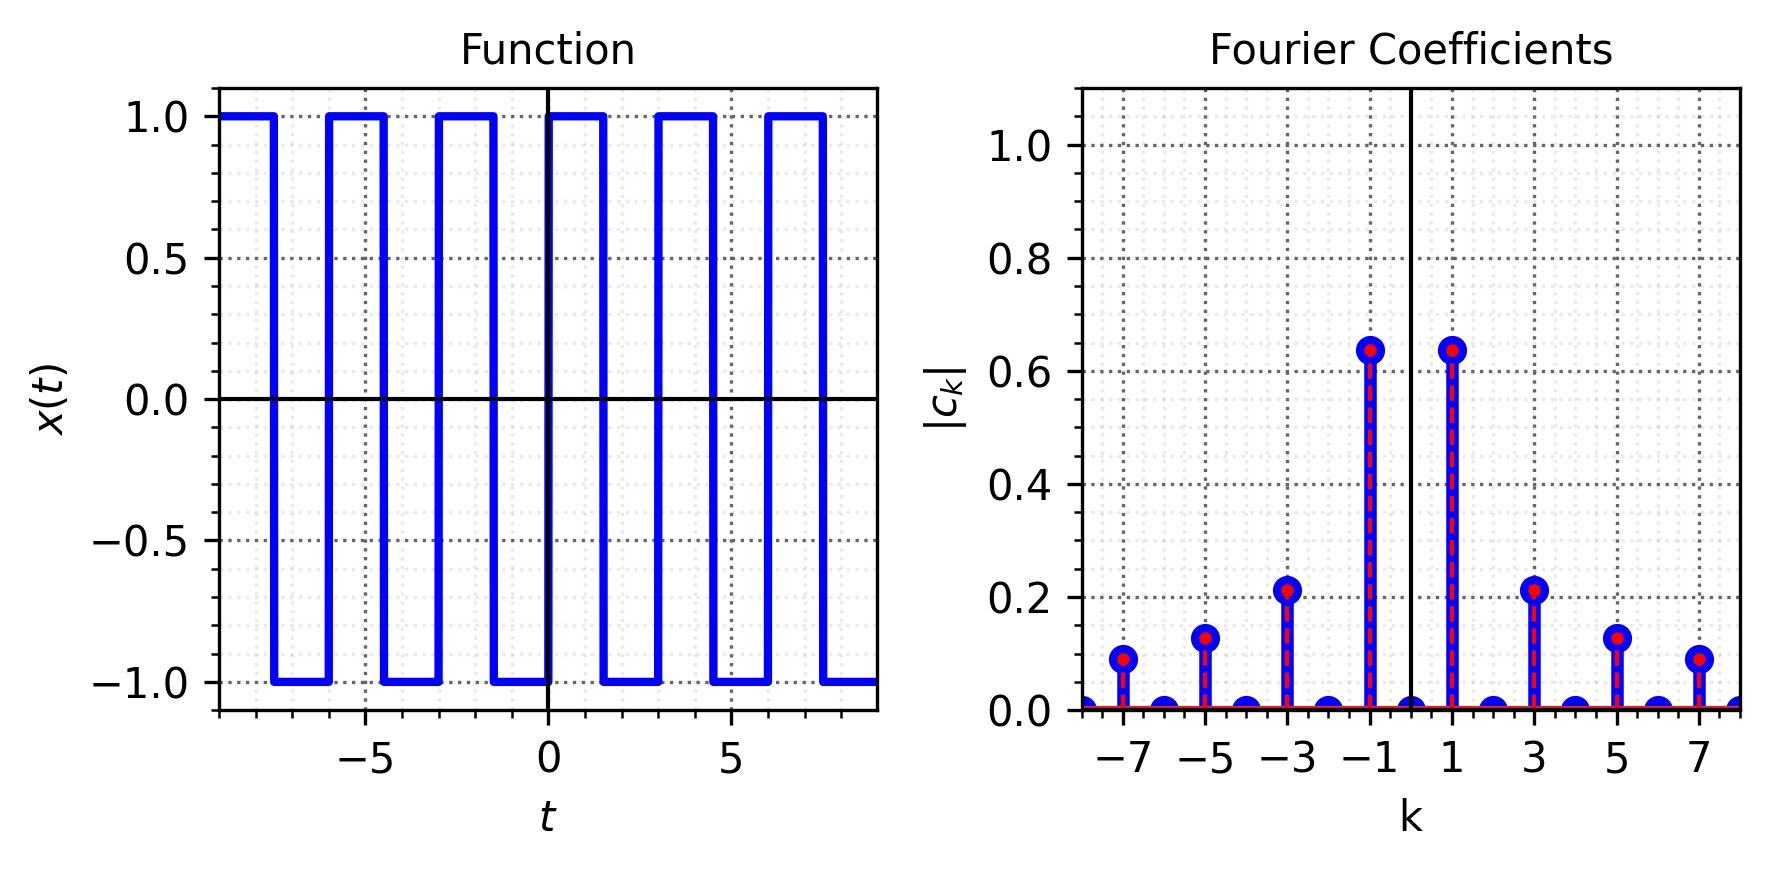

In [9]:
T0 = 3
x4 = lambda t: sc.signal.square(2 * np.pi * t/ T0)  

# FUAY pg210
A = 1;kn = np.arange(-7,8,2); bn = lambda n: 4*A/np.pi/abs(n)  

C_ex4 = compute_ck(T0,x4)
plot_fourier_coeffs(T0,x4,C_ex4,kn=kn,bn=bn)


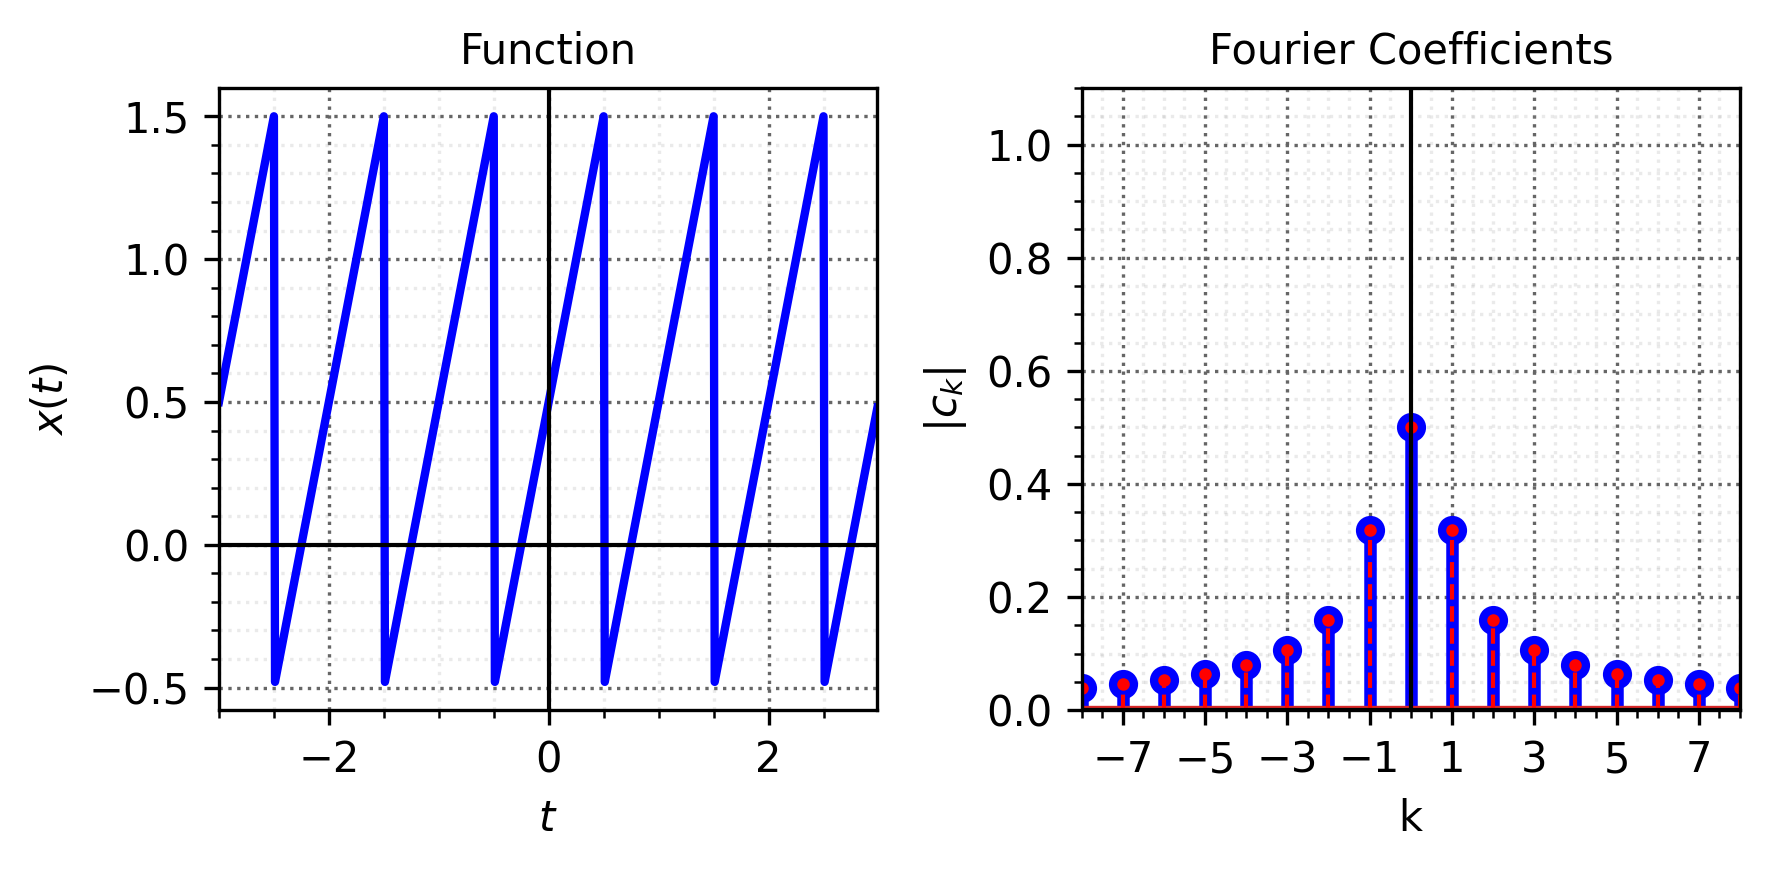

In [10]:
T0 = 1; offset = 0.5
x5 = lambda t: offset + sc.signal.sawtooth(2 * np.pi * t/ T0 + np.pi)  

# FUAY pg210
A = 1;kn = np.arange(-8,9); bn = lambda n: (-1)**(abs(n)+1)*2*A/np.pi/abs(n)  if abs(n) != 0 else 2*offset 

C_ex5 = compute_ck(T0,x5)
plot_fourier_coeffs(T0,x5,C_ex5,kn,bn=bn)

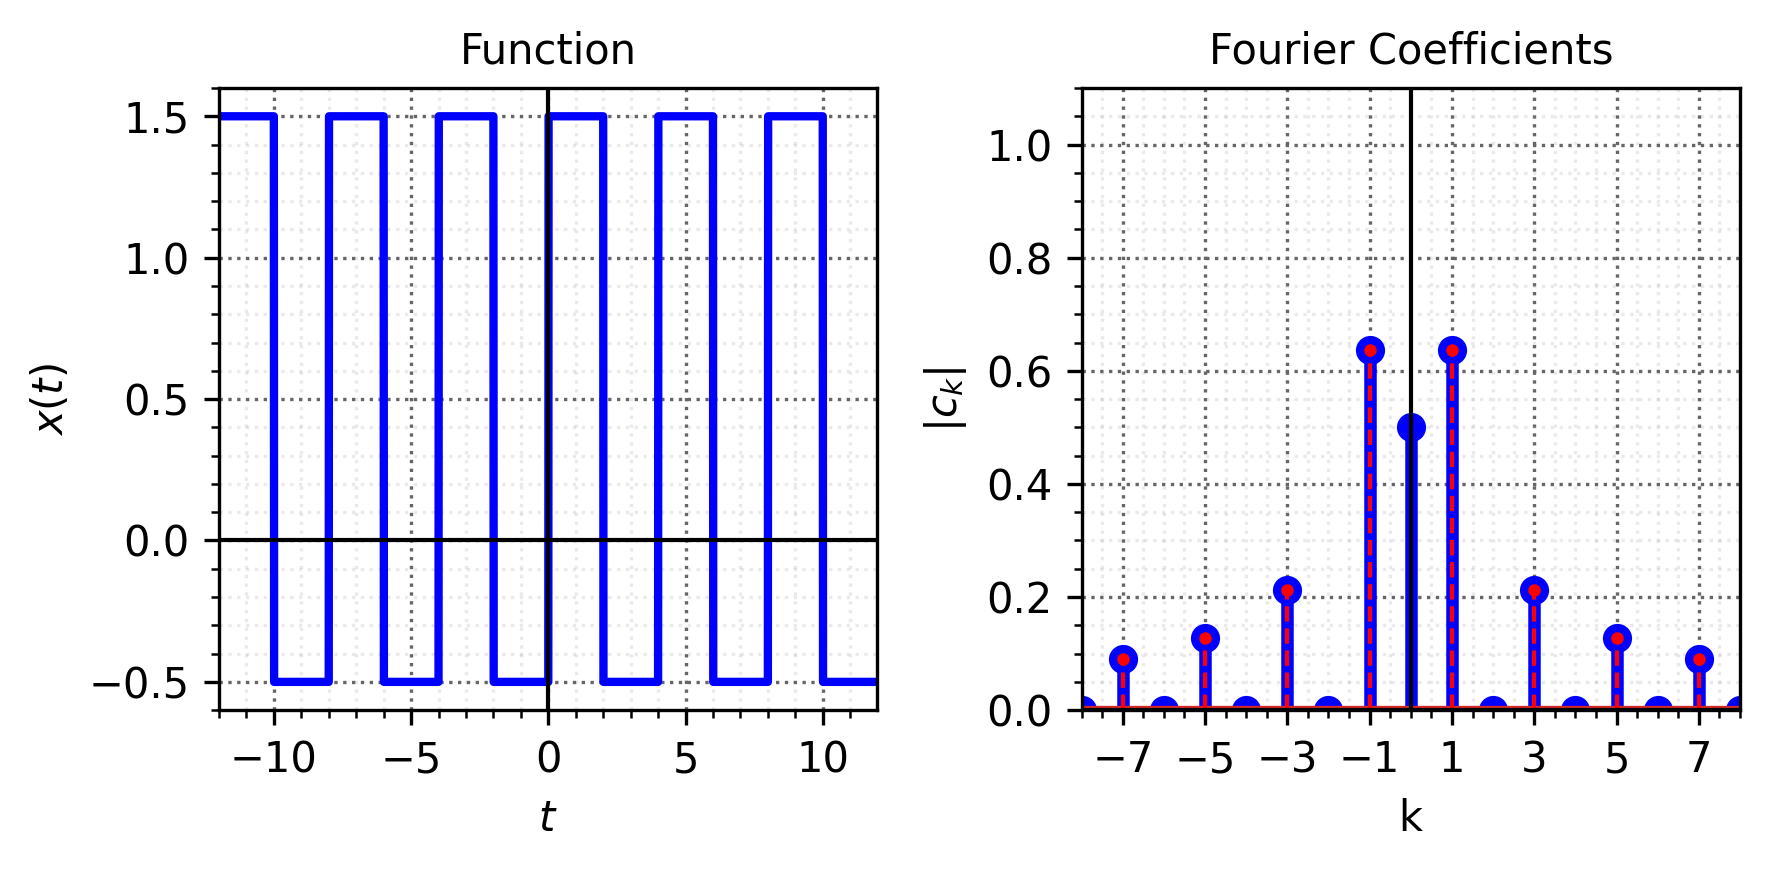

In [11]:
T0 = 4
x5 = lambda t: 0.5 + sc.signal.square(2 * np.pi * t/ T0)  

# FUAY pg210
A = 1;kn = np.arange(-7,8,2); bn = lambda n: 4*A/np.pi/abs(n)  

C_ex5 = compute_ck(T0,x5)
plot_fourier_coeffs(T0,x5,C_ex5,kn=kn,bn=bn)

## Periodicity discussion

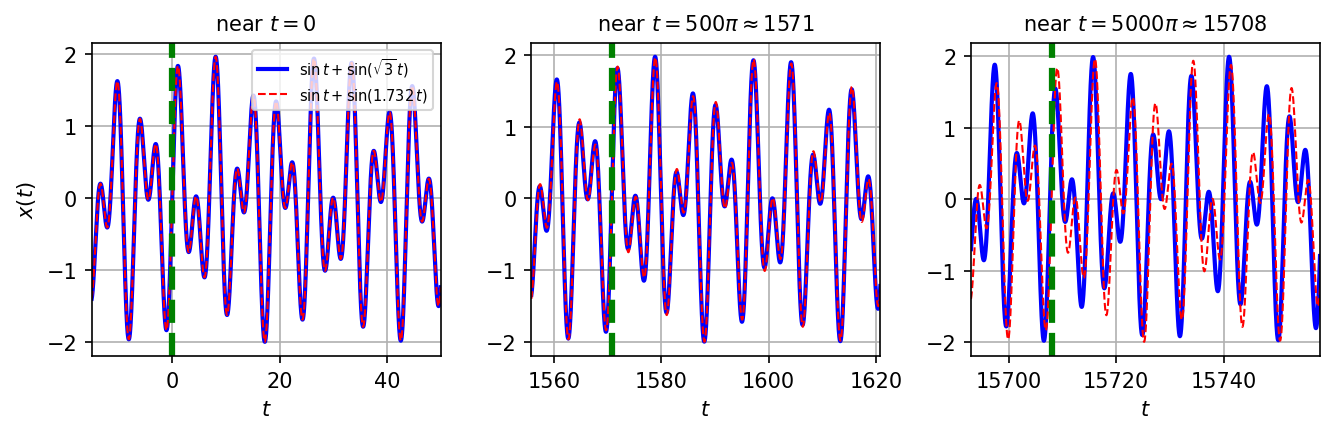

In [12]:
import numpy as np, matplotlib.pyplot as plt
T = 500*np.pi                     # period of the 1.732 signal (= 2π·250)
def x_irr(t): return np.sin(t) + np.sin(np.sqrt(3)*t)   # not periodic
def x_rat(t): return np.sin(t) + np.sin(1.732*t)        # periodic, T=500π

fig, (axL, axC, axR) = plt.subplots(1, 3, figsize=(9, 3), dpi=150, gridspec_kw={'width_ratios':[1, 1, 1]})
for ax, t0, ttl in [(axL, 0, 'near $t=0$'), (axC, T, rf'near $t=500\pi\approx{T:.0f}$'), (axR, 10*T, rf'near $t=5000\pi\approx{10*T:.0f}$')]:
    t = np.linspace(t0-15, t0+50, 4000)
    ax.plot(t, x_irr(t), 'b-',  lw=2, label=r'$\sin t+\sin(\sqrt{3}\,t)$')
    ax.plot(t, x_rat(t), 'r--', lw=1, label=r'$\sin t+\sin(1.732\,t)$')
    ax.set_title(ttl); ax.set_xlabel('$t$'); ax.grid(True)
    ax.axvline(t0, color='g', linestyle='--', lw=3)
axL.set_ylabel('$x(t)$'); axL.legend(fontsize=7, loc='upper right')
fig.tight_layout()
fig.savefig('figs/T6_periodicity.pdf')


In [13]:
10*T

15707.963267948964